# GEMM-KKT Experiment Interpretation Guide

This notebook explains:
- what each solver/method is doing,
- how experiments are configured, and
- how to interpret the generated summary tables and plots.


## Methods in this repo

- **`gemm_ipm_ns` (`ns_ipm`)**: Primal-dual IPM with factorization-free NS inverse + refinement (`kkt_mode=ns_only`).
- **`gemm_ipm_robust` (`ns_ipm_rb`)**: Same IPM, but can switch to NS-preconditioned Krylov when NS contraction is poor (`kkt_mode=robust`).
- **`gemm_splitting_qp` (`split_qp`)**: ADMM/OSQP-style splitting method with CG+NS or NS linear solve.
- **`lp_first_order_gpu` (`lp_pdhg_gpu`)**: first-order LP solver (PDHG/PDLP-style).
- **`scipy_trust_constr_cpu` (`scipy_trust_cpu`)**: CPU baseline via SciPy trust-constr (single-instance wrapper).
- **`osqp_cpu` / `highs_cpu`**: optional CPU baselines when installed.


## Experimental setup (high-level)

Main QP family is dense batched parametric QP:
\n
\[\n
\min_x \; \tfrac12 x^T P x + q^T x \quad \text{s.t.}\quad l \le Ax \le u\n
\]

Typical presets:
- `ns_favor`: easier/moderate conditioning, large multi-RHS batches.
- `mixed`: moderate-to-hard conditioning.
- `stress`: hardest among standard presets.
- `a100_heavy`: very large dense configs targeting long 8xA100 runs.

Important table column interpretation:
- `n` in summary table = number of run records, **not problem dimension**.
- `solved` = count with status `solved`.
- `t_med_s` is more robust than `t_mean_s` when there are outliers/failures.
- `g_mean` may be `NaN` for methods whose wrappers do not expose duality gap (e.g., SciPy wrapper).


In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = [json.loads(line) for line in path.open() if line.strip()]
    return pd.json_normalize(rows)

# Simple repo-local defaults from notebooks/: ../results/comprehensive/...
if 'combined_results_path' not in globals() or combined_results_path is None:
    combined_results_path = Path('../results/comprehensive/combined_results.jsonl').resolve()
if 'manifest_path' not in globals() or manifest_path is None:
    manifest_path = Path('../results/comprehensive/manifest.csv').resolve()

if not combined_results_path.exists():
    raise FileNotFoundError(f'combined_results not found: {combined_results_path}')
if not manifest_path.exists():
    raise FileNotFoundError(f'manifest not found: {manifest_path}')

print('combined_results_path:', combined_results_path)
print('manifest_path       :', manifest_path)

df = load_jsonl(combined_results_path)
manifest = pd.read_csv(manifest_path)

for c in ['timing.median_s', 'metrics.primal_residual', 'metrics.dual_residual', 'metrics.duality_gap']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'metadata.comprehensive_case' in df.columns:
    df['case'] = df['metadata.comprehensive_case']
elif 'metadata.overnight_case' in df.columns:
    df['case'] = df['metadata.overnight_case']
else:
    df['case'] = 'unknown'

df['preset'] = df['case'].astype(str).str.split('_s').str[0]

print('rows:', len(df))
print('solvers:', sorted(df['solver'].dropna().unique()))
print('status counts:\n', df['status'].value_counts(dropna=False))
display(manifest)


combined_results_path: /Users/jlylekim/Documents/New project/results/comprehensive/combined_results.jsonl
manifest_path       : /Users/jlylekim/Documents/New project/results/comprehensive/manifest.csv
rows: 104
solvers: ['gemm_ipm_ns', 'gemm_ipm_robust', 'gemm_splitting_qp', 'lp_first_order_gpu', 'scipy_trust_constr_cpu']
status counts:
 status
solved       92
max_iters    12
Name: count, dtype: int64


,case,status,duration_s,output_dir,args
0,a100_heavy_s0,failed,4038,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset a100_heavy --seed 0
1,a100_heavy_s1,failed,3703,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset a100_heavy --seed 1
2,a100_heavy_s2,failed,3880,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset a100_heavy --seed 2
3,a100_heavy_s3,failed,4211,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset a100_heavy --seed 3
4,stress_s0,ok,1829,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset stress --seed 0
5,stress_s1,ok,638,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset stress --seed 1
6,stress_s2,ok,3035,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset stress --seed 2
7,stress_s3,ok,1896,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset stress --seed 3
8,mixed_s0,failed,6050,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset mixed --seed 0
9,mixed_s1,failed,7267,/home/sagemaker-user/user-default-efs/jlk/matm...,--preset mixed --seed 1


In [3]:
# Guard cell: ensures setup has already run.
if 'df' not in globals() or 'manifest' not in globals():
    raise RuntimeError('Run the setup cell above first (it resolves paths and loads data).')

print('Data ready:', len(df), 'rows')


Data ready: 104 rows


In [4]:
solver_summary = df.groupby('solver').agg(
    n=('solver', 'size'),
    solved=('status', lambda s: (s == 'solved').sum()),
    t_med_s=('timing.median_s', 'median'),
    t_mean_s=('timing.median_s', 'mean'),
    t_std_s=('timing.median_s', 'std'),
    p_mean=('metrics.primal_residual', 'mean'),
    d_mean=('metrics.dual_residual', 'mean'),
    g_mean=('metrics.duality_gap', 'mean'),
).sort_values('t_med_s')

preset_solver_summary = df.groupby(['preset', 'solver']).agg(
    n=('solver', 'size'),
    solved=('status', lambda s: (s == 'solved').sum()),
    t_med_s=('timing.median_s', 'median'),
    t_mean_s=('timing.median_s', 'mean'),
    p_mean=('metrics.primal_residual', 'mean'),
    d_mean=('metrics.dual_residual', 'mean'),
    g_mean=('metrics.duality_gap', 'mean'),
).reset_index().sort_values(['preset', 'solver'])

display(solver_summary)
display(preset_solver_summary)


,n,solved,t_med_s,t_mean_s,t_std_s,p_mean,d_mean,g_mean
solver,,,,,,,,
gemm_splitting_qp,24,24,0.066536,0.075265,0.034539,0.000098,9.185621e-03,NaN
gemm_ipm_ns,24,24,0.097619,0.102415,0.017024,0.000000,2.390617e-07,0.003924
gemm_ipm_robust,32,24,0.185839,5.148878,8.807019,0.003745,2.042132e-02,0.002921
scipy_trust_constr_cpu,16,16,24.172512,32.940803,29.300985,0.000000,5.955133e-03,NaN
lp_first_order_gpu,8,4,72.117723,73.005661,72.871941,0.020386,1.616308e+00,-925403.198541


,preset,solver,n,solved,t_med_s,t_mean_s,p_mean,d_mean,g_mean
0,stress,gemm_ipm_ns,24,24,0.097619,0.102415,0.000000,2.390617e-07,0.003924
1,stress,gemm_ipm_robust,32,24,0.185839,5.148878,0.003745,2.042132e-02,0.002921
2,stress,gemm_splitting_qp,24,24,0.066536,0.075265,0.000098,9.185621e-03,NaN
3,stress,lp_first_order_gpu,8,4,72.117723,73.005661,0.020386,1.616308e+00,-925403.198541
4,stress,scipy_trust_constr_cpu,16,16,24.172512,32.940803,0.000000,5.955133e-03,NaN


## How problem instances are generated (difficulty drivers)

### 1) Dense parametric QP (`dense_parametric_qp.py`)
For each case, the generator builds:
- SPD Hessian `P = Q diag(vals) Q^T` with log-spaced eigenvalues up to `condition_number`.
- Random constraint matrix `A ~ N(0, 1/sqrt(n))`.
- Reference `x_ref`, then `q = -P x_ref + 0.05 * noise`.
- Two-sided bounds around `A x_ref`: `l = A x_ref - slack`, `u = A x_ref + slack`, with `slack ~ tightness * (1 + U[0,1])`.

Main knobs affecting difficulty:
- `n, m` (problem size),
- `batch_size * rhs_count` (aggregate workload),
- `condition_number` (ill-conditioning),
- `tightness` (smaller means tighter feasible corridor).

### 2) Portfolio QP (`portfolio_qp.py`)
- Covariance model `Sigma = F F^T + diag(D)`, objective uses `P = risk_scale * Sigma + 1e-4 I`.
- Constraints: budget equality (`sum x = 1`) + box (`0 <= x_i <= max_weight`).
- Key difficulty knobs: `n_assets`, `n_factors`, `max_weight`, batch size.

### 3) Batched LP (`batched_lp.py`)
- Random `A`, synthetic feasible `b = A x_ref`, random cost `c`.
- Difficulty mostly from `n, m, batch_size` and first-order iteration behavior.


In [5]:
# Extract difficulty-relevant config fields from logged metadata.config
cfg_cols = [
    'metadata.config.batch_size', 'metadata.config.rhs_count',
    'metadata.config.n', 'metadata.config.m',
    'metadata.config.condition_number', 'metadata.config.tightness',
    'metadata.config.n_assets', 'metadata.config.n_factors',
    'metadata.config.max_weight',
]

for c in cfg_cols:
    if c not in df.columns:
        df[c] = np.nan

for c in cfg_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

meta = df[[
    'preset', 'case', 'problem_id', 'solver',
    'metadata.config.batch_size', 'metadata.config.rhs_count',
    'metadata.config.n', 'metadata.config.m',
    'metadata.config.condition_number', 'metadata.config.tightness',
    'metadata.config.n_assets', 'metadata.config.n_factors',
    'metadata.config.max_weight',
]].copy()

meta['family'] = np.where(meta['problem_id'].astype(str).str.contains('dense_parametric'), 'dense_parametric_qp',
                    np.where(meta['problem_id'].astype(str).str.contains('portfolio'), 'portfolio_qp',
                    np.where(meta['problem_id'].astype(str).str.contains('_lp_'), 'batched_lp', 'other')))

meta['rhs_count'] = meta['metadata.config.rhs_count'].fillna(1)
meta['batch_size'] = meta['metadata.config.batch_size']
meta['total_batch'] = meta['batch_size'] * meta['rhs_count']

# Size proxies (not exact FLOPs, but useful for relative difficulty)
meta['dense_size_proxy'] = meta['total_batch'] * meta['metadata.config.n'] * meta['metadata.config.m']
meta['portfolio_size_proxy'] = meta['batch_size'] * meta['metadata.config.n_assets'] * (meta['metadata.config.n_assets'] + meta['metadata.config.n_factors'])
meta['lp_size_proxy'] = meta['batch_size'] * meta['metadata.config.n'] * meta['metadata.config.m']

# One row per (case, problem_id) for readability
case_problem = (meta.sort_values(['case','problem_id'])
               .groupby(['preset','case','problem_id','family'], as_index=False)
               .first())

display(case_problem[['preset','case','problem_id','family','batch_size','rhs_count','total_batch',
                     'metadata.config.n','metadata.config.m','metadata.config.condition_number','metadata.config.tightness',
                     'metadata.config.n_assets','metadata.config.n_factors','metadata.config.max_weight',
                     'dense_size_proxy','portfolio_size_proxy','lp_size_proxy']].sort_values(['preset','case','problem_id']))


,preset,case,problem_id,family,batch_size,rhs_count,total_batch,metadata.config.n,metadata.config.m,metadata.config.condition_number,metadata.config.tightness,metadata.config.n_assets,metadata.config.n_factors,metadata.config.max_weight,dense_size_proxy,portfolio_size_proxy,lp_size_proxy
0,stress,stress_s0,main_dense_parametric_0,dense_parametric_qp,128.0,4.0,512.0,256.0,512.0,100000.0,0.20,NaN,NaN,NaN,67108864.0,NaN,16777216.0
1,stress,stress_s0,main_dense_parametric_1,dense_parametric_qp,96.0,3.0,288.0,384.0,768.0,300000.0,0.15,NaN,NaN,NaN,84934656.0,NaN,28311552.0
2,stress,stress_s0,main_dense_parametric_2,dense_parametric_qp,64.0,2.0,128.0,512.0,1024.0,700000.0,0.12,NaN,NaN,NaN,67108864.0,NaN,33554432.0
3,stress,stress_s0,main_dense_parametric_3,dense_parametric_qp,48.0,2.0,96.0,640.0,1280.0,1000000.0,0.10,NaN,NaN,NaN,78643200.0,NaN,39321600.0
4,stress,stress_s0,main_lp_0,batched_lp,256.0,1.0,256.0,512.0,256.0,NaN,NaN,NaN,NaN,NaN,33554432.0,NaN,33554432.0
5,stress,stress_s0,main_lp_1,batched_lp,192.0,1.0,192.0,768.0,384.0,NaN,NaN,NaN,NaN,NaN,56623104.0,NaN,56623104.0
6,stress,stress_s0,main_portfolio_0,portfolio_qp,128.0,1.0,128.0,NaN,NaN,NaN,NaN,256.0,12.0,0.2,NaN,8781824.0,NaN
7,stress,stress_s0,main_portfolio_1,portfolio_qp,96.0,1.0,96.0,NaN,NaN,NaN,NaN,384.0,16.0,0.2,NaN,14745600.0,NaN
8,stress,stress_s0,strong_dense_parametric_0,dense_parametric_qp,512.0,2.0,1024.0,192.0,384.0,10000.0,0.20,NaN,NaN,NaN,75497472.0,NaN,37748736.0
9,stress,stress_s0,weak_dense_parametric_0,dense_parametric_qp,512.0,2.0,1024.0,192.0,384.0,10000.0,0.20,NaN,NaN,NaN,75497472.0,NaN,37748736.0


### Reading difficulty from the table

For dense parametric QP, difficulty generally rises with:
- larger `n, m`,
- larger `total_batch = batch_size * rhs_count`,
- larger `condition_number`,
- smaller `tightness` (tighter constraints).

If a preset/case failed early, it may not appear in this extracted table because no final records were written.


In [6]:
# Representative case: pick first successful stress case if available, else first successful case
ok_cases = manifest.loc[manifest['status'] == 'ok', 'case'].tolist()
rep_case = None
for c in ok_cases:
    if str(c).startswith('stress_'):
        rep_case = c
        break
if rep_case is None and ok_cases:
    rep_case = ok_cases[0]

print('representative case:', rep_case)
rep = df[df['case'] == rep_case].copy()

display(rep[['solver', 'problem_id', 'status', 'timing.median_s', 'metrics.primal_residual', 'metrics.dual_residual', 'metrics.duality_gap']].sort_values(['solver', 'problem_id']))


representative case: stress_s0


,solver,problem_id,status,timing.median_s,metrics.primal_residual,metrics.dual_residual,metrics.duality_gap
0,gemm_ipm_ns,main_dense_parametric_0,solved,0.082147,0.000000,3.805193e-07,4.809325e-03
4,gemm_ipm_ns,main_dense_parametric_1,solved,0.100795,0.000000,3.126161e-07,3.601465e-03
8,gemm_ipm_ns,main_dense_parametric_2,solved,0.111869,0.000000,2.379428e-07,2.881657e-03
12,gemm_ipm_ns,main_dense_parametric_3,solved,0.133376,0.000000,2.108810e-07,2.401297e-03
20,gemm_ipm_ns,strong_dense_parametric_0,solved,0.088264,0.000000,1.457162e-07,4.819507e-03
23,gemm_ipm_ns,weak_dense_parametric_0,solved,0.088181,0.000000,1.466224e-07,4.819716e-03
1,gemm_ipm_robust,main_dense_parametric_0,solved,0.105264,0.000000,1.559276e-07,4.817710e-03
5,gemm_ipm_robust,main_dense_parametric_1,solved,0.164261,0.000000,1.700006e-07,3.614741e-03
9,gemm_ipm_robust,main_dense_parametric_2,solved,0.191303,0.000000,1.873133e-07,2.892175e-03
13,gemm_ipm_robust,main_dense_parametric_3,solved,0.209358,0.000000,1.810716e-07,2.407514e-03


,solver,metric,total_points,positive_points,zero_or_negative,nan_points
1,gemm_ipm_ns,dual_residual,6,6,0,0
3,gemm_ipm_robust,dual_residual,8,8,0,0
5,gemm_splitting_qp,dual_residual,6,6,0,0
7,lp_first_order_gpu,dual_residual,2,2,0,0
9,scipy_trust_constr_cpu,dual_residual,4,4,0,0
0,gemm_ipm_ns,primal_residual,6,0,6,0
2,gemm_ipm_robust,primal_residual,8,2,6,0
4,gemm_splitting_qp,primal_residual,6,0,6,0
6,lp_first_order_gpu,primal_residual,2,2,0,0
8,scipy_trust_constr_cpu,primal_residual,4,0,4,0


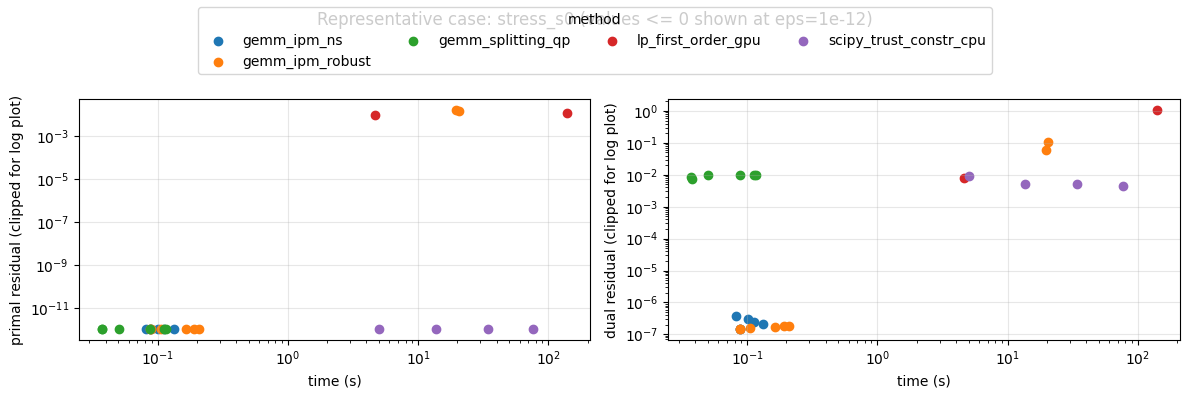

In [7]:
# Quick visual for representative case (log-scale safe)
# Note: log plots require positive y-values. Some methods report exact 0 primal residual,
# which would disappear unless we clip to a tiny epsilon for visualization.
eps = 1e-12
rep_plot = rep.copy()

diag_rows = []
for solver, g in rep_plot.groupby('solver'):
    for metric in ['metrics.primal_residual', 'metrics.dual_residual']:
        y = pd.to_numeric(g[metric], errors='coerce')
        total = int(len(y))
        finite = y[np.isfinite(y)]
        pos = int((finite > 0).sum())
        zero_or_neg = int((finite <= 0).sum())
        nan_count = int(total - len(finite))
        diag_rows.append({
            'solver': solver,
            'metric': metric.replace('metrics.', ''),
            'total_points': total,
            'positive_points': pos,
            'zero_or_negative': zero_or_neg,
            'nan_points': nan_count,
        })

diag = pd.DataFrame(diag_rows).sort_values(['metric', 'solver'])
display(diag)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for solver, g in rep_plot.groupby('solver'):
    x = pd.to_numeric(g['timing.median_s'], errors='coerce').to_numpy()

    yp = pd.to_numeric(g['metrics.primal_residual'], errors='coerce').to_numpy()
    yd = pd.to_numeric(g['metrics.dual_residual'], errors='coerce').to_numpy()

    # Clip nonpositive values so they remain visible on log scale.
    yp_clip = np.where(np.isfinite(yp) & (yp > 0), yp, eps)
    yd_clip = np.where(np.isfinite(yd) & (yd > 0), yd, eps)

    mask_p = np.isfinite(x) & np.isfinite(yp_clip) & (x > 0)
    mask_d = np.isfinite(x) & np.isfinite(yd_clip) & (x > 0)

    axes[0].scatter(x[mask_p], yp_clip[mask_p], label=solver)
    axes[1].scatter(x[mask_d], yd_clip[mask_d], label=solver)

for ax, ylab in zip(axes, ['primal residual (clipped for log plot)', 'dual residual (clipped for log plot)']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time (s)')
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=min(4, len(labels)), title='method')
fig.suptitle(f'Representative case: {rep_case} (values <= 0 shown at eps={eps:g})')
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


## Interpreting missing methods on primal log plots

If a method is missing from the primal-residual plot, it usually means its primal residual is exactly `0` (or nonpositive/NaN) for those points.

Because the y-axis is log-scale, matplotlib only draws points with `y > 0`.

For NS-IPM in your run, primal residuals are often exactly zero at the reported precision, so points can disappear on raw log plots.
This does **not** mean the method only outputs dual variables. The solver computes both primal and dual metrics; it is a plotting-domain issue.


In [8]:
# Dataset-level diagnostic: how many points would be dropped on raw log plots
rows = []
for solver, g in df.groupby('solver'):
    for metric in ['metrics.primal_residual', 'metrics.dual_residual']:
        y = pd.to_numeric(g[metric], errors='coerce')
        total = len(y)
        finite = y[np.isfinite(y)]
        kept_raw_log = int((finite > 0).sum())
        dropped_raw_log = int(total - kept_raw_log)
        rows.append({
            'solver': solver,
            'metric': metric.replace('metrics.', ''),
            'total_points': int(total),
            'kept_on_raw_log_plot': kept_raw_log,
            'dropped_on_raw_log_plot': dropped_raw_log,
        })
drop_diag = pd.DataFrame(rows).sort_values(['metric', 'solver'])
display(drop_diag)


,solver,metric,total_points,kept_on_raw_log_plot,dropped_on_raw_log_plot
1,gemm_ipm_ns,dual_residual,24,24,0
3,gemm_ipm_robust,dual_residual,32,32,0
5,gemm_splitting_qp,dual_residual,24,24,0
7,lp_first_order_gpu,dual_residual,8,8,0
9,scipy_trust_constr_cpu,dual_residual,16,16,0
0,gemm_ipm_ns,primal_residual,24,0,24
2,gemm_ipm_robust,primal_residual,32,8,24
4,gemm_splitting_qp,primal_residual,24,3,21
6,lp_first_order_gpu,primal_residual,8,8,0
8,scipy_trust_constr_cpu,primal_residual,16,0,16


## How to interpret failures / empty folders

If a case folder (e.g., `mixed_s*`, `a100_heavy_s*`) is empty or missing `results.jsonl`, it typically means the case crashed before `reproduce.py` reached final write-out. Common causes:
- OOM or CUDA runtime failure on very large dense batches,
- solver exception in one experiment within that case,
- distributed launch failure (one rank aborts and tears down all ranks).

Use `manifest.csv` first:
- `status=failed` means that case did not complete end-to-end.
- rows in `combined_results.jsonl` therefore represent only successful cases.


## Practical reading checklist

1. Check manifest success/failure by case and preset.
2. Confirm which presets are actually represented in `combined_results.jsonl`.
3. Compare methods first on `t_med_s`, then verify `solved` and residual quality.
4. Treat `t_mean_s` carefully if there are max-iter outliers.
5. For claims, report both aggregate and per-preset results.
